# Introduction to Probabilistic Machine Learning
### Lecture 1: Foundations & Code Demonstrations
**Instructor:** Aayush Sugandh | [YouTube Video Link](https://youtu.be/kMkCOrp8te8?si=zIziszYRn7hzBUOe)

This Google Colab notebook accompanies **Lecture 1** of the Probabilistic Machine Learning course. Below, each major concept taught in the lecture is thoroughly explained mathematically and conceptually, followed by fully executable Python code demonstrations.

---

## 1. What is Machine Learning? (Tom Mitchell's Definition)
According to Prof. Tom Mitchell, a computer program is said to learn from **Experience ($E$)** with respect to some class of **Tasks ($T$)** and **Performance Measure ($P$)**, if its performance at tasks in $T$, as measured by $P$, improves with experience $E$.

- **Experience ($E$):** The dataset $\mathcal{D} = \{(x_1, y_1), (x_2, y_2), \dots, (x_N, y_N)\}$ containing $N$ observed samples.
- **Task ($T$):** The target mapping function $f: \mathcal{X} \rightarrow \mathcal{Y}$ (e.g., classification or regression).
- **Performance Measure ($P$):** Evaluation metrics like accuracy, misclassification rate, or negative log-likelihood (NLL).

Let's import our core scientific computing libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Set random seed for reproducibility
np.random.seed(42)
print("Libraries successfully imported!")

Libraries successfully imported!


## 2. Probabilistic Perspective: Random Variables & Distributions
In deterministic systems, outcomes are strictly predictable. In machine learning, quantities of interest (e.g., weather tomorrow, true labels, model weights) are unknown or stochastic.

### What is a Random Variable?
A **random variable** $X$ is a *deterministic mapping function* $X: \Omega \rightarrow \mathbb{R}$ from a sample space of random events \Omega to numerical values on the real line \mathbb{R}.
- As noted in the lecture: *A random variable is neither random nor a variable!*
  - It is not random because the mapping function itself is deterministic.
  - It is not a variable because it is a mathematical function.
  - The randomness lies in the underlying outcome generation mechanism of the physical world.

### Code Demo: Coin Flip Experiment (Bernoulli Trial)
We simulate tossing a coin with probability $p=0.6$ of getting Heads (1).

True Probability p: 0.6
Empirical Mean from 1000 trials: 0.6130


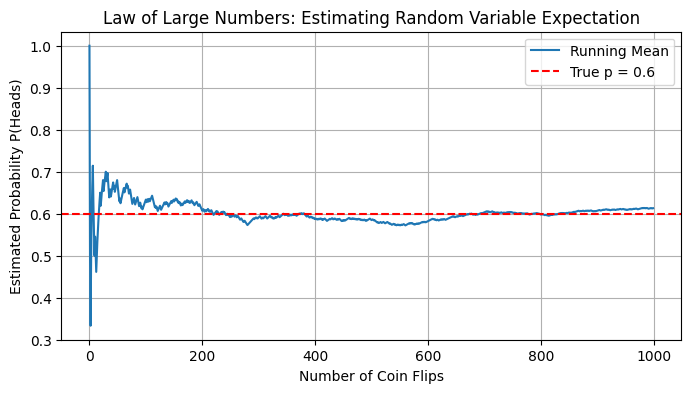

In [ ]:
# Simulate 1,000 flips of a coin with P(Heads = 1) = 0.6
p_true = 0.6
n_trials = 1000
coin_flips = np.random.binomial(n=1, p=p_true, size=n_trials)

empirical_mean = np.mean(coin_flips)
print(f"True Probability p: {p_true}")
print(f"Empirical Mean from {n_trials} trials: {empirical_mean:.4f}")

# Plot convergence over trials
running_means = np.cumsum(coin_flips) / (np.arange(n_trials) + 1)
plt.figure(figsize=(8, 4))
plt.plot(running_means, label="Running Mean")
plt.axhline(p_true, color='r', linestyle='--', label=f"True p = {p_true}")
plt.xlabel("Number of Coin Flips")
plt.ylabel("Estimated Probability P(Heads)")
plt.title("Law of Large Numbers: Estimating Random Variable Expectation")
plt.legend()
plt.grid(True)
plt.show()

## 3. Supervised Machine Learning & Iris Dataset
In **Supervised Machine Learning**, we are given a dataset $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N$ of $N$ examples:
- $x_i \in \mathbb{R}^D$: Feature vector (covariates / inputs).
- $y_i \in \mathcal{Y}$: Label or response variable.
- **Design Matrix ($X$):** An $N \times D$ matrix where each row represents one data example and each column represents a feature.

### Classification Task
If $\mathcal{Y} = \{1, 2, \dots, C\}$ (unordered, mutually exclusive classes), the task is **Multi-class Classification** (also known as Pattern Recognition).
In the lecture, we introduced the **Iris dataset**, which consists of:
- $N = 150$ samples of flowers.
- $D = 4$ features: Petal Length, Petal Width, Sepal Length, Sepal Width.
- $C = 3$ target classes: *Setosa* (0), *Versicolor* (1), *Virginica* (2).

In [ ]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data  # Design matrix N x D
y = iris.target  # Labels
feature_names = iris.feature_names
class_names = iris.target_names

print(f"Design Matrix X Shape: {X.shape} (N={X.shape[0]} samples, D={X.shape[1]} features)")
print(f"Classes (C={len(class_names)}): {class_names}")

# Construct pandas DataFrame to display design matrix tabular structure
df_iris = pd.DataFrame(X, columns=feature_names)
df_iris['target_label'] = [class_names[i] for i in y]
df_iris.head()

Design Matrix X Shape: (150, 4) (N=150 samples, D=4 features)
Classes (C=3): ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target_label
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 4. Exploratory Data Analysis (EDA)
Why do EDA before applying a model?
1. **Identify feature correlations & redundancies:** Features might be highly correlated, allowing feature selection or dimensionality reduction.
2. **Detect anomalies & noise:** Clean out bad measurements or uninformative features.
3. **Understand separability:** Check if decision boundaries can be easily constructed.

We plot pair-plots across the 4 features and compute feature-to-feature correlations.

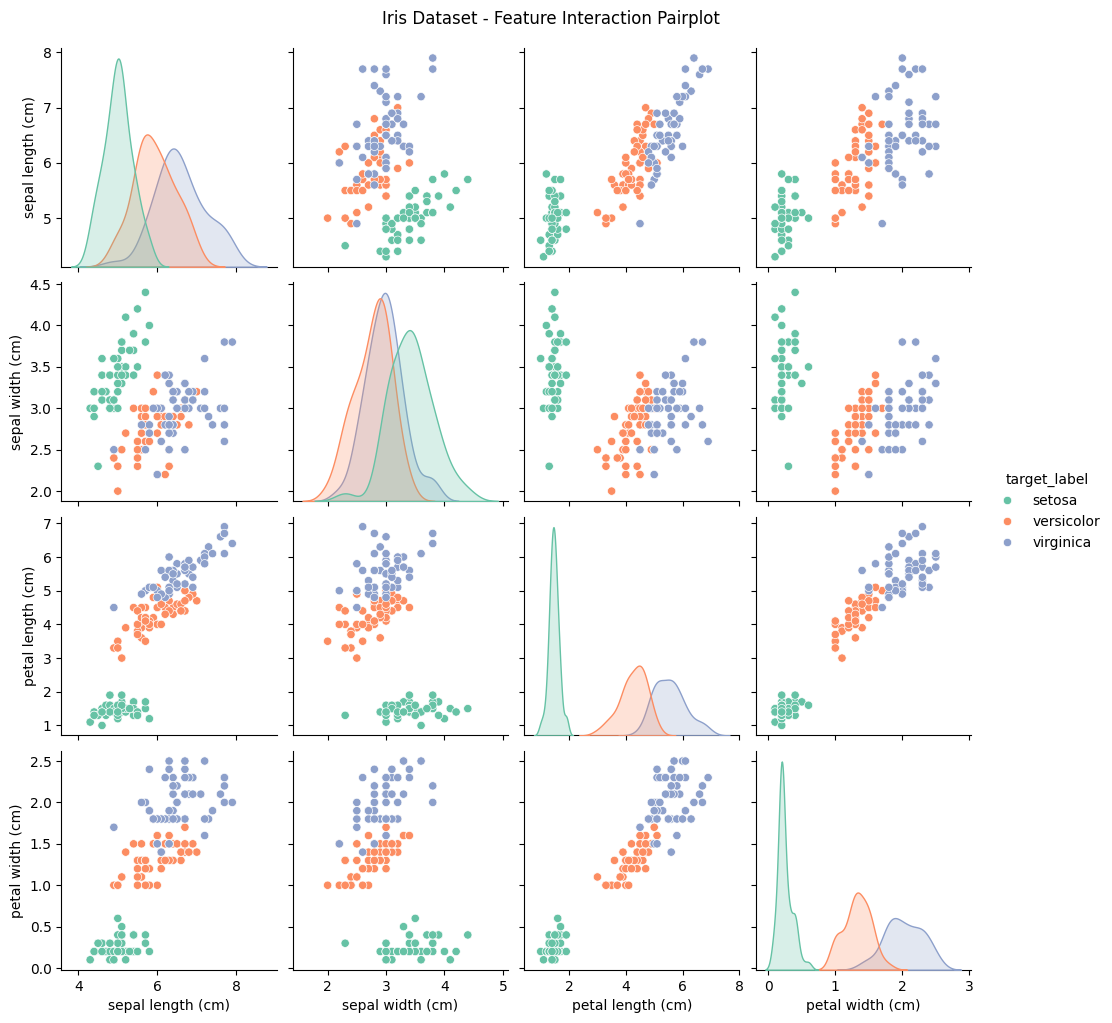

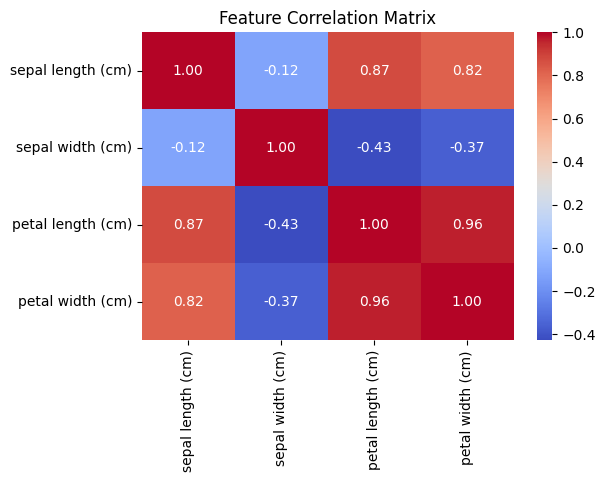

In [ ]:
# Pairplot visualization across features colored by species
sns.pairplot(df_iris, hue='target_label', palette='Set2')
plt.suptitle("Iris Dataset - Feature Interaction Pairplot", y=1.02)
plt.show()

# Feature Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(pd.DataFrame(X, columns=feature_names).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

## 5. Learning Classifiers: Decision Trees & Nested Boundaries
To classify flowers, we want to learn a decision boundary $f(x; \theta)$.
In the lecture's whiteboard example, we split the feature space hierarchically:
1. **Root Split:** Is $\text{Petal Length} \le \alpha$? If True $\rightarrow$ Classify as **Setosa** (50 samples).
2. **Nested Split:** If False, check if $\text{Petal Width} \le \beta$? If True $\rightarrow$ **Versicolor**, else $\rightarrow$ **Virginica**.

The threshold parameters $\alpha, \beta$ must be **automatically learned** by the ML algorithm, rather than manually hardcoded.

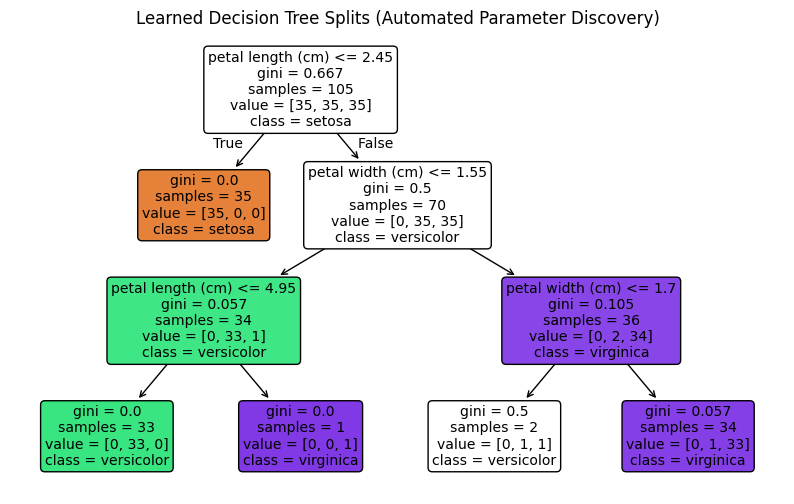

In [ ]:
# Train-Test Split (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train Decision Tree Classifier matching the lecture whiteboard logic
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Visualize the learned Decision Tree splits
plt.figure(figsize=(10, 6))
plot_tree(dt_model, feature_names=feature_names, class_names=class_names, filled=True, rounded=True)
plt.title("Learned Decision Tree Splits (Automated Parameter Discovery)")
plt.show()

## 6. Empirical Risk Minimization (ERM)
To evaluate how well parameters $\theta$ fit our training data, we define a **loss function** $\ell(y, f(x; \theta))$.

### Misclassification Rate (0-1 Loss)
Using the indicator function $\mathbb{I}(\cdot)$:
$$\mathcal{L}_{0-1}(\theta) = \frac{1}{N} \sum_{i=1}^N \mathbb{I}\left(f(x_i; \theta) \ne y_i\right)$$

### General Asymmetric Loss Function
In practice, misclassifying certain classes (e.g. eating a poisonous flower like Virginica) incurs higher risk than others. Thus we use a general loss metric $\ell(y_i, f(x_i; \theta))$:
$$\mathcal{L}_{\text{Empirical}}(\theta) = \frac{1}{N} \sum_{i=1}^N \ell\left(y_i, f(x_i; \theta)\right)$$

**Empirical Risk Minimization (ERM)** finds parameter set $\hat{\theta}_{ERM}$:
$$\hat{\theta}_{ERM} = \arg\min_{\theta} \frac{1}{N} \sum_{i=1}^N \ell\left(y_i, f(x_i; \theta)\right)$$

In [ ]:
# Compute Empirical Training Misclassification Loss
y_train_pred = dt_model.predict(X_train)
train_misclass_rate = 1.0 - accuracy_score(y_train, y_train_pred)

print(f"Empirical 0-1 Misclassification Risk on Training Set: {train_misclass_rate:.4f}")

Empirical 0-1 Misclassification Risk on Training Set: 0.0190


## 7. Generalization: Minimizing Expected Loss on Future Data
Minimizing training loss alone is not the true goal of Machine Learning. The true goal is **Generalization**: minimizing expected loss on unseen future data sampled from the data distribution $\mathcal{P}_{X, Y}$:
$$\mathcal{R}_{\text{true}}(\theta) = \mathbb{E}_{(X,Y) \sim \mathcal{P}_{X,Y}} \left[ \ell(Y, f(X; \theta)) \right]$$

We evaluate performance on held-out **test data** to estimate generalization ability.

In [ ]:
# Compute Test Set Performance (Proxy for Expected Generalization Risk)
y_test_pred = dt_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_misclass_rate = 1.0 - test_accuracy

print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy (Generalization Estimate): {test_accuracy:.4f}")
print(f"Test Misclassification Risk: {test_misclass_rate:.4f}")

Training Accuracy: 0.9810
Test Accuracy (Generalization Estimate): 0.9778
Test Misclassification Risk: 0.0222


## 8. Types of Uncertainty: Epistemic vs. Aleatoric
Machine Learning systems are stochastic. Real-world uncertainty comes in two forms:
1. **Epistemic (Model) Uncertainty:** Uncertainty due to lack of knowledge or limited training data. This uncertainty *can be reduced* by acquiring more training samples or refining the model.
2. **Aleatoric (Data) Uncertainty:** Inherent, irreducible randomness in the physical process (e.g., coin flip dynamics, sensor measurement noise). This *cannot be reduced* even with infinite data.

Below, we simulate aleatoric measurement noise added to features to demonstrate irreducible classification error.

In [ ]:
# Add stochastic aleatoric noise to dataset features
noise_level = 0.8
X_noisy = X + np.random.normal(loc=0.0, scale=noise_level, size=X.shape)

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X_noisy, y, test_size=0.3, random_state=42, stratify=y)

noisy_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
noisy_tree.fit(X_tr_n, y_tr_n)
acc_noisy = accuracy_score(y_te_n, noisy_tree.predict(X_te_n))

print(f"Clean Data Test Accuracy: {test_accuracy:.4f}")
print(f"Noisy Data Test Accuracy (Aleatoric Uncertainty Impact): {acc_noisy:.4f}")

Clean Data Test Accuracy: 0.9778
Noisy Data Test Accuracy (Aleatoric Uncertainty Impact): 0.6000


## 9. Softmax Function: Converting Logits to Probabilities
To express model uncertainty, our predictor $f(x; \theta)$ outputs raw real-valued scores called **logits** $\mathbf{a} = [a_1, a_2, \dots, a_C]^T \in \mathbb{R}^C$.

To map logits to valid conditional class probabilities $P(Y=c \mid X=x; \theta)$, we pass them through the **Softmax function**:
$$\text{Softmax}(\mathbf{a})_c = \frac{e^{a_c}}{\sum_{c'=1}^C e^{a_{c'}}}$$

**Properties:**
1. $0 \le \text{Softmax}(\mathbf{a})_c \le 1, \quad \forall c \in \{1, \dots, C\}$
2. $\sum_{c=1}^C \text{Softmax}(\mathbf{a})_c = 1$

In [ ]:
def softmax(logits):
    """Numerically stable Softmax function."""
    exp_logits = np.exp(logits - np.max(logits, axis=-1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

# Example logits for 3 classes
sample_logits = np.array([[2.5, 1.0, 0.2],
                          [0.1, 3.2, 0.5]])

probs = softmax(sample_logits)
print("Raw Logits:")
print(sample_logits)
print("\nConverted Softmax Probabilities:")
print(probs)
print("\nSum of Probabilities per sample:", probs.sum(axis=1))

Raw Logits:
[[2.5 1.  0.2]
 [0.1 3.2 0.5]]

Converted Softmax Probabilities:
[[0.75563572 0.16860512 0.07575916]
 [0.0405026  0.89907463 0.06042277]]

Sum of Probabilities per sample: [1. 1.]


## 10. Linear Models & Bias Absorption
A standard linear model predicts scores using weights $\mathbf{w}$ and bias $b$:
$$f(x) = \mathbf{w}^T x + b$$

To simplify mathematical notation and avoid tracking bias parameter $b$ separately, we perform **Bias Absorption** by prepending a constant feature $1$ to feature vector $x$:
$$\tilde{x} = \begin{bmatrix} 1 \\ x_1 \\ \vdots \\ x_D \end{bmatrix}, \quad \tilde{\mathbf{w}} = \begin{bmatrix} b \\ w_1 \\ \vdots \\ w_D \end{bmatrix} \implies f(x) = \tilde{\mathbf{w}}^T \tilde{x}$$

In [ ]:
# Demonstrate Bias Absorption in numpy
ones_column = np.ones((X.shape[0], 1))
X_tilde = np.hstack([ones_column, X])

print(f"Original Feature Shape X: {X.shape}")
print(f"Augmented Feature Shape X_tilde: {X_tilde.shape}")
print("First row of X_tilde:", X_tilde[0])

Original Feature Shape X: (150, 4)
Augmented Feature Shape X_tilde: (150, 5)
First row of X_tilde: [1.  5.1 3.5 1.4 0.2]


## 11. Maximum Likelihood Estimation (MLE) & Negative Log-Likelihood (NLL)
For probabilistic model fitting, we seek parameters $\theta$ that maximize the probability of observing our true labels given the inputs.

### Likelihood Function
Assuming i.i.d. data points:
$$\mathcal{L}(\theta) = \prod_{i=1}^N P(y_i \mid x_i; \theta)$$

### Negative Log-Likelihood (NLL) Loss
Taking the log converts products to sums, and multiplying by $-\frac{1}{N}$ gives the standard **NLL Loss**:
$$\text{NLL}(\theta) = -\frac{1}{N} \sum_{i=1}^N \log P(y_i \mid x_i; \theta)$$

Maximizing Likelihood $\mathcal{L}(\theta)$ is mathematically identical to Minimizing NLL Loss $\text{NLL}(\theta)$:
$$\hat{\theta}_{MLE} = \arg\max_{\theta} \mathcal{L}(\theta) = \arg\min_{\theta} \text{NLL}(\theta)$$

In [ ]:
# Fit Multinomial Logistic Regression model using MLE (Minimizing NLL)
mle_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
mle_model.fit(X_train, y_train)

# Obtain predicted class probabilities P(y | x)
y_test_probs = mle_model.predict_proba(X_test)

# Calculate Negative Log-Likelihood (NLL / Log Loss)
nll_loss = log_loss(y_test, y_test_probs)
accuracy_lr = accuracy_score(y_test, mle_model.predict(X_test))

print(f"Logistic Regression Test Accuracy: {accuracy_lr:.4f}")
print(f"Negative Log-Likelihood (NLL Loss): {nll_loss:.4f}")

Logistic Regression Test Accuracy: 0.9333
Negative Log-Likelihood (NLL Loss): 0.1818


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 12. Complete End-to-End ML Pipeline Function
We encapsulate all steps from preprocessing, model fitting, probability prediction, and NLL calculation into an automated function.

In [ ]:
def run_probabilistic_ml_pipeline(X, y, classifier, test_size=0.3, random_state=42):
    """Runs complete train-test split, model training, evaluation, and NLL loss computation."""
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

    classifier.fit(X_tr, y_tr)
    preds = classifier.predict(X_te)
    probs = classifier.predict_proba(X_te)

    acc = accuracy_score(y_te, preds)
    nll = log_loss(y_te, probs)

    print(f"Model: {classifier.__class__.__name__}")
    print(f"-> Test Accuracy: {acc:.4f}")
    print(f"-> Negative Log-Likelihood (NLL): {nll:.4f}\n")
    return classifier

# Test pipeline with Logistic Regression
_ = run_probabilistic_ml_pipeline(X, y, LogisticRegression(max_iter=500))
# Test pipeline with Decision Tree
_ = run_probabilistic_ml_pipeline(X, y, DecisionTreeClassifier(max_depth=3))

Model: LogisticRegression
-> Test Accuracy: 0.9333
-> Negative Log-Likelihood (NLL): 0.1818

Model: DecisionTreeClassifier
-> Test Accuracy: 0.9333
-> Negative Log-Likelihood (NLL): 0.1473



## 13. Summary & Key Takeaways
1. **Definition of ML:** Experience ($E$), Task ($T$), Performance ($P$).
2. **Random Variables:** Deterministic mappings from outcome sample spaces to real numbers.
3. **Supervised Learning:** Learning mapping $f: X \rightarrow Y$ over design matrix $X$.
4. **Decision Boundaries:** Hierarchical nested splits learned automatically via parameters $\theta$.
5. **ERM vs. Generalization:** Minimizing training loss vs. expected loss on unseen future data.
6. **Uncertainty:** Distinguishing Epistemic (model knowledge) vs. Aleatoric (data noise).
7. **Softmax & MLE:** Converting raw logits to calibrated probabilities and estimating parameters by minimizing Negative Log-Likelihood (NLL).